# **Chess Win Predictor**

## **Abstract**

Chess engines tell you who *should* win given perfect play, but most online games aren't decided that way. I wanted to see how well you can predict the outcome using the kind of information that actually matters in human games: rating gap, time pressure, and a lightweight snapshot of the board position. The data comes from Lichess's February 2026 export. I filtered it down to 8.6 million completed 10-minute rapid games and built a pipeline that tests everything from logistic regression up to recurrent neural networks. Models are evaluated at 5-move landmarks rather than as a single average, which gives a clearer picture of where predictions are actually useful. The best result was a PyTorch SimpleRNN trained on all 8.6M games: `63.6%` test accuracy and `74.2%` average landmark accuracy. Better features mattered more than a fancier model.

## **Introduction**

The usual way to estimate who's winning a chess game is engine evaluation. Give Stockfish the position and it'll tell you the centipawn score. But that answers a different question than "who's going to win this specific game between two humans with a clock running." A player can be objectively worse on the board and still win because their opponent flags on time, or because a 400-point rating gap means one player just makes fewer practical mistakes. I was interested in whether you could build a decent win predictor from *those* signals instead.

The Lichess Open Database gives you everything you need: PGN files with player Elos, clock annotations after every move, and termination types. The tricky parts are data quality (the raw dump is a mix of time controls, disconnects, and abandoned games) and data leakage (the model should only ever see what was available at the moment of the move, not anything from later in the game). Both of those shaped a lot of the design decisions below.

## **Methodology**

### Data filtering

The raw PGN for February 2026 is 27.7 GB compressed and has 84.6 million games covering every time control and a lot of incomplete games. I wrote a streaming filter (`filter_lichess_pgn.py`) that keeps only games where:

1. `TimeControl == "600+0"` (standard 10-minute rapid, no increment)
2. `Termination == "Normal"` (ended by checkmate or resignation, not a disconnect)

Streaming one game at a time was the only practical option given the file size. After filtering, 8.6 million games remained.

### Feature extraction

I built two feature sets, going from simpler to richer.

**Light features** just use what's in the PGN headers and move annotations: player Elos, remaining clock for both sides, time spent on the last move, some derived ratios, and simple flags from the SAN notation (capture, check, castle, promotion). No board reconstruction needed.

**Board-aware features** add a position snapshot using `python-chess`. After each move the script records material counts, material imbalance, number of legal moves, castling rights, bishop pair status, and the halfmove clock. The snapshot is always taken *after* the move is played, so there's no future-move information leaking in.

### Training and scaling

For small runs (up to 10k games) I exported features to a flat CSV and trained sklearn models on it. At larger scale that stops working since the CSVs get huge and you can't stream them. So for the RNN experiments I switched to NPZ shards: each game's full board-aware sequence gets written to a compressed shard during extraction, with the train/val/test split enforced at the game level. The PyTorch trainer then streams those shards with persistent workers and mixed precision, and saves epoch checkpoints so long runs can be paused.

### Evaluation

Splits are always game-level, not row-level. Every snapshot from a given game lands in the same split. Hyperparameters were chosen on the validation set; test numbers were only checked at the end.

The main evaluation metric is **landmark accuracy**: rather than averaging over every move (which overweights long games), I pull one snapshot per game every 5 full moves. This gives a per-stage curve so you can see how prediction confidence evolves from opening to endgame.

## **Experimental Setup**

### Dataset

| Stage | Count |
|---|---|
| Raw games in monthly export | 84,600,043 |
| After filtering (`600+0`, `Termination=Normal`) | 8,633,881 |
| Train / Validation / Test (full dataset) | 6,214,945 / 690,252 / 1,726,823 |

Smaller subsets of `1k`, `10k`, `50k`, `100k`, `250k`, and `1M` games were used for iterative development before the final full-dataset run.

### Running the pipeline

Filtering:

```python
!python scripts/filter_lichess_pgn.py \
    --input lichess_db_standard_rated_2026-02/lichess_db_standard_rated_2026-02.pgn \
    --output data/lichess_rapid_10_0_completed.pgn \
    --time-control 600+0 --termination Normal
```

Board-aware feature extraction (CSV, for small-scale runs):

```python
!python scripts/extract_lichess_board_features.py \
    --input data/lichess_rapid_10_0_completed.pgn \
    --output data/dev_board_features_1000_games.csv --max-games 1000
```

Shard extraction (for large-scale RNN training):

```python
!python scripts/extract_rnn_game_shards_parallel.py \
    --input data/lichess_rapid_10_0_completed.pgn \
    --output-dir data/rnn_shards_250000 --max-games 250000 --workers 2
```

### Models compared

| Family | Variants tested |
|---|---|
| **Light logistic regression** | Logistic regression on Elo + clock + SAN-shape features |
| **Light gradient boosting** | Histogram gradient boosting on the same light feature set |
| **Board logistic regression** | Logistic regression on the full board-aware feature set |
| **Board gradient boosting / XGBoost** | Histogram gradient boosting and XGBoost on board-aware features |
| **Board SVM** | `LinearSVC` with sigmoid probability calibration |
| **Board MLP** | 2-3 hidden layer configurations; one draw-oversampled variant |
| **Keras RNN sweep** | `SimpleRNN(64)`, `GRU(64)`, `LSTM(64)`, stacked GRU, dropout and loss-weighting variants, all on the `1k` development set |
| **PyTorch SimpleRNN** | `RNN(input=41, hidden=64)` from NPZ shards with CUDA mixed precision; scaled from `1k` to all `8.6M` games |

All recurrent models are trained on **game prefix sequences**: each training example is the board-aware feature sequence from move 1 up to a 5-move landmark, and the label is the final game outcome (White win / Black win / Draw).

## **How to Use This Notebook in Google Colab**

There are two ways to run this notebook.

### Lightweight run (for graders)

The fast path. Clones the repo, loads archived results from `artifacts/reported_results/`, and optionally runs a small end-to-end smoke test on a 60-game sample. No large files needed.

**Steps:**

1. **Run Cell 6 (Setup)**: clones the repo and installs dependencies.
2. **Run Cell 7 (Load results)**: prints the SimpleRNN scaling table and the 250k PyTorch RNN reported metrics from the tracked artifact files.
3. **Run Cell 8 (Smoke test, optional)**: runs the full pipeline (filter, extract, shard, train) on a tiny 60-game sample in a few minutes on a standard Colab CPU runtime.

All cells can be run top-to-bottom with **Runtime > Run all**.



### Full reproduction (requires large data files)

> **Important context:** The main experimental work for this project was done **outside of Google Colab**, on a local Windows machine with an NVIDIA RTX 3060 GPU. The raw Lichess PGN for February 2026 is **27.7 GB compressed** and contains **84.6 million games**. After filtering to completed 10-minute rapid games, the result is still **8.6 million games**, which is not feasible on a free Colab runtime.

Full reproduction requires either uploading the pre-filtered `lichess_rapid_10_0_completed.pgn` to Colab or Google Drive, or starting from the raw Lichess PGN (even larger), then running the extraction and training scripts documented in the Experimental Setup section. The archived results in `artifacts/reported_results/` were generated from those full runs and represent the numbers reported in the tables below.

The notebook is the readable report; the external scripts in `scripts/` contain the modular pipeline code. Links to each key script are provided inline in the Methodology section.

### Tracked reproducibility assets

Small files tracked in Git (safe to commit):

- `artifacts/sample_data/colab_dev_60_games.pgn`
- `artifacts/sample_data/sample_rapid_10_0_completed.pgn`
- `artifacts/reported_results/dev_board_logreg_metrics_1000_games.json`
- `artifacts/reported_results/torch_rnn_landmark_board_250000_with_history.json`
- `artifacts/reported_results/simplernn_scaling_summary.csv`

These are separate from `data/`, which stays git-ignored to avoid committing multi-gigabyte intermediate files.

In [ ]:
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/thermoNuke1/ml-PROJECT.git"
REPO_NAME = "ml-PROJECT"
REPO_PATH = Path(f"/content/{REPO_NAME}")

os.chdir("/content")

if not REPO_PATH.is_dir():
    !git clone {REPO_URL} {REPO_PATH}
else:
    print("Already cloned - pulling latest changes")
    !git -C {REPO_PATH} pull

requirements_path = REPO_PATH / "requirements.txt"
if requirements_path.exists():
    !pip install -q -r {requirements_path}
else:
    print("No requirements.txt found - using the current notebook environment")

repo_path_str = str(REPO_PATH)
if repo_path_str not in sys.path:
    sys.path.insert(0, repo_path_str)

os.chdir(REPO_PATH)
print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {repo_path_str}")


In [1]:
from pathlib import Path
import json
import pandas as pd

# archived results live in artifacts/reported_results/; data/ is git-ignored
artifacts_dir = Path('artifacts/reported_results')

scaling_path = artifacts_dir / 'simplernn_scaling_summary.csv'
if scaling_path.exists():
    scaling_df = pd.read_csv(scaling_path)
    print("SimpleRNN scaling summary:")
    display(scaling_df)
else:
    print(f'scaling summary not found at {scaling_path}')

rnn_path = artifacts_dir / 'torch_rnn_landmark_board_250000_with_history.json'
if rnn_path.exists():
    payload = json.loads(rnn_path.read_text(encoding='utf-8'))
    print("\n250k PyTorch SimpleRNN reported results:")
    print({k: payload[k] for k in ['test_accuracy', 'test_log_loss', 'train_games', 'test_games']})
else:
    print(f'250k RNN metrics not found at {rnn_path}')


ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Smoke test on a 60-game sample (~2-4 min on CPU). Outputs go to artifacts/colab_runs/.

import subprocess, sys

result = subprocess.run(
    [sys.executable, 'scripts/run_colab_repro.py', '--run-rnn-smoke', '--rnn-epochs', '2'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)


## **Experimental Results**

### Features matter more than model choice

The clearest finding across all experiments: what you feed the model matters more than which model you use. Adding board-state features caused a much bigger accuracy jump than switching from logistic regression to gradient boosting or an MLP.

Light features (Elo + clock + SAN shape) got logistic regression to `45.7%` and histogram gradient boosting to `46.1%`, basically identical and barely above a naive Elo baseline. Once I switched to board-aware features, logistic regression alone jumped to `57.2%` on 1k games and `61.1%` on 10k. That gap held across every model I tried.

### Tree-based and SVM models

Histogram gradient boosting on board-aware features was a disappointment. Log loss of `1.826` because it basically gave up on predicting draws. XGBoost on 10k games (`59.8%`, log loss `0.844`) was better but still trailed logistic regression.

The calibrated linear SVM ended up being the strongest non-RNN model. At 10k games: `61.0%` accuracy, log loss `0.795`, average landmark accuracy of `65.7%`. Pretty close to logistic regression on every metric.

### MLP models

MLPs were consistently bad at probability calibration despite decent accuracy numbers (~`54-55%`). Log loss ranged from 3 to 5+ depending on the architecture. The draw class was especially poorly handled, the MLPs mostly just predicted White win or Black win. None of the architecture variants I tried fixed this, which is why I moved on to recurrent models.

### Recurrent models

RNNs have a natural advantage here because they see the whole game sequence up to the current position rather than a single snapshot. Even on just 1k games, `SimpleRNN(64)` hit `59.8%` test accuracy and log loss `0.807`, already competitive with snapshot models that had more training data.

I ran a sweep of RNN variants on 1k games using Keras before committing to a larger-scale approach. The best single variant was a `GRU(64)` with dropout `0.2` and upweighted loss on moves 20-50 (weight `1.5`), reaching `61.9%` accuracy and log loss `0.774`.

### Overall model comparison

| Model | Dataset | Evaluation | Test Accuracy | Test Log Loss | Avg Landmark Accuracy | Avg Landmark Brier | Move 5 Acc | Move 10 Acc | Move 20 Acc | Move 30 Acc | Move 40 Acc |
|---|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Light Logistic Regression | 1k | Snapshot | 0.457 | 0.911 | 0.441 | 0.579 | 0.472 | 0.487 | 0.437 | 0.453 | 0.383 |
| Light HistGradientBoosting | 1k | Snapshot | 0.461 | 2.221 | 0.440 | 0.899 | 0.451 | 0.465 | 0.457 | 0.443 | 0.433 |
| Board Logistic Regression | 1k | Snapshot | 0.572 | 0.837 | 0.607 | 0.492 | 0.467 | 0.535 | 0.576 | 0.594 | 0.700 |
| Board Logistic Regression | 10k | Snapshot | 0.611 | 0.795 | 0.665 | 0.455 | 0.525 | 0.559 | 0.639 | 0.694 | 0.683 |
| Board SVM (calibrated linear) | 1k | Snapshot | 0.578 | 0.818 | 0.606 | 0.493 | 0.472 | 0.535 | 0.570 | 0.585 | 0.717 |
| Board SVM (calibrated linear) | 10k | Snapshot | 0.610 | 0.795 | 0.657 | 0.458 | 0.527 | 0.559 | 0.642 | 0.693 | 0.679 |
| Board HistGradientBoosting | 1k | Snapshot | 0.539 | 1.826 | 0.559 | 0.722 | 0.492 | 0.471 | 0.570 | 0.576 | 0.583 |
| Board XGBoost | 10k | Snapshot | 0.598 | 0.844 | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| Board MLP (128,64) | 1k | Snapshot | 0.541 | 3.280 | 0.556 | 0.772 | 0.487 | 0.481 | 0.517 | 0.519 | 0.583 |
| Board Deep MLP (256,128,64) | 1k | Snapshot | 0.543 | 3.668 | 0.555 | 0.779 | 0.451 | 0.497 | 0.556 | 0.576 | 0.583 |
| Board Deep MLP (256,128,64) | 10k | Snapshot | 0.545 | 3.072 | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| Board Balanced MLP (256,128,64)+OS | 10k | Snapshot | 0.542 | 2.935 | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| Board Wide MLP (512,256,128) | 10k | Snapshot | 0.541 | 5.626 | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| Basic SimpleRNN | 1k | Landmark Sequence | 0.598 | 0.807 | 0.628 | 0.471 | 0.513 | 0.562 | 0.636 | 0.651 | 0.750 |
| Basic SimpleRNN | 10k | Landmark Sequence | 0.615 | 0.774 | 0.672 | 0.424 | 0.529 | 0.536 | 0.628 | 0.687 | 0.701 |
| Basic SimpleRNN | 250k | Landmark Sequence | 0.628 | 0.763 | 0.689 | 0.420 | 0.529 | 0.555 | 0.640 | 0.703 | 0.714 |
| Basic SimpleRNN | 8.63M | Landmark Sequence | 0.636 | 0.749 | 0.742 | 0.353 | 0.534 | 0.563 | 0.650 | 0.709 | 0.724 |
| Best Tuned GRU (dropout + midgame weighting) | 1k | Landmark Sequence | 0.619 | 0.774 | 0.637 | 0.442 | 0.528 | 0.540 | 0.642 | 0.585 | 0.783 |
| Best Tuned GRU (dropout + midgame weighting) | 10k | Landmark Sequence | 0.622 | 0.769 | 0.669 | 0.427 | 0.536 | 0.545 | 0.647 | 0.697 | 0.685 |

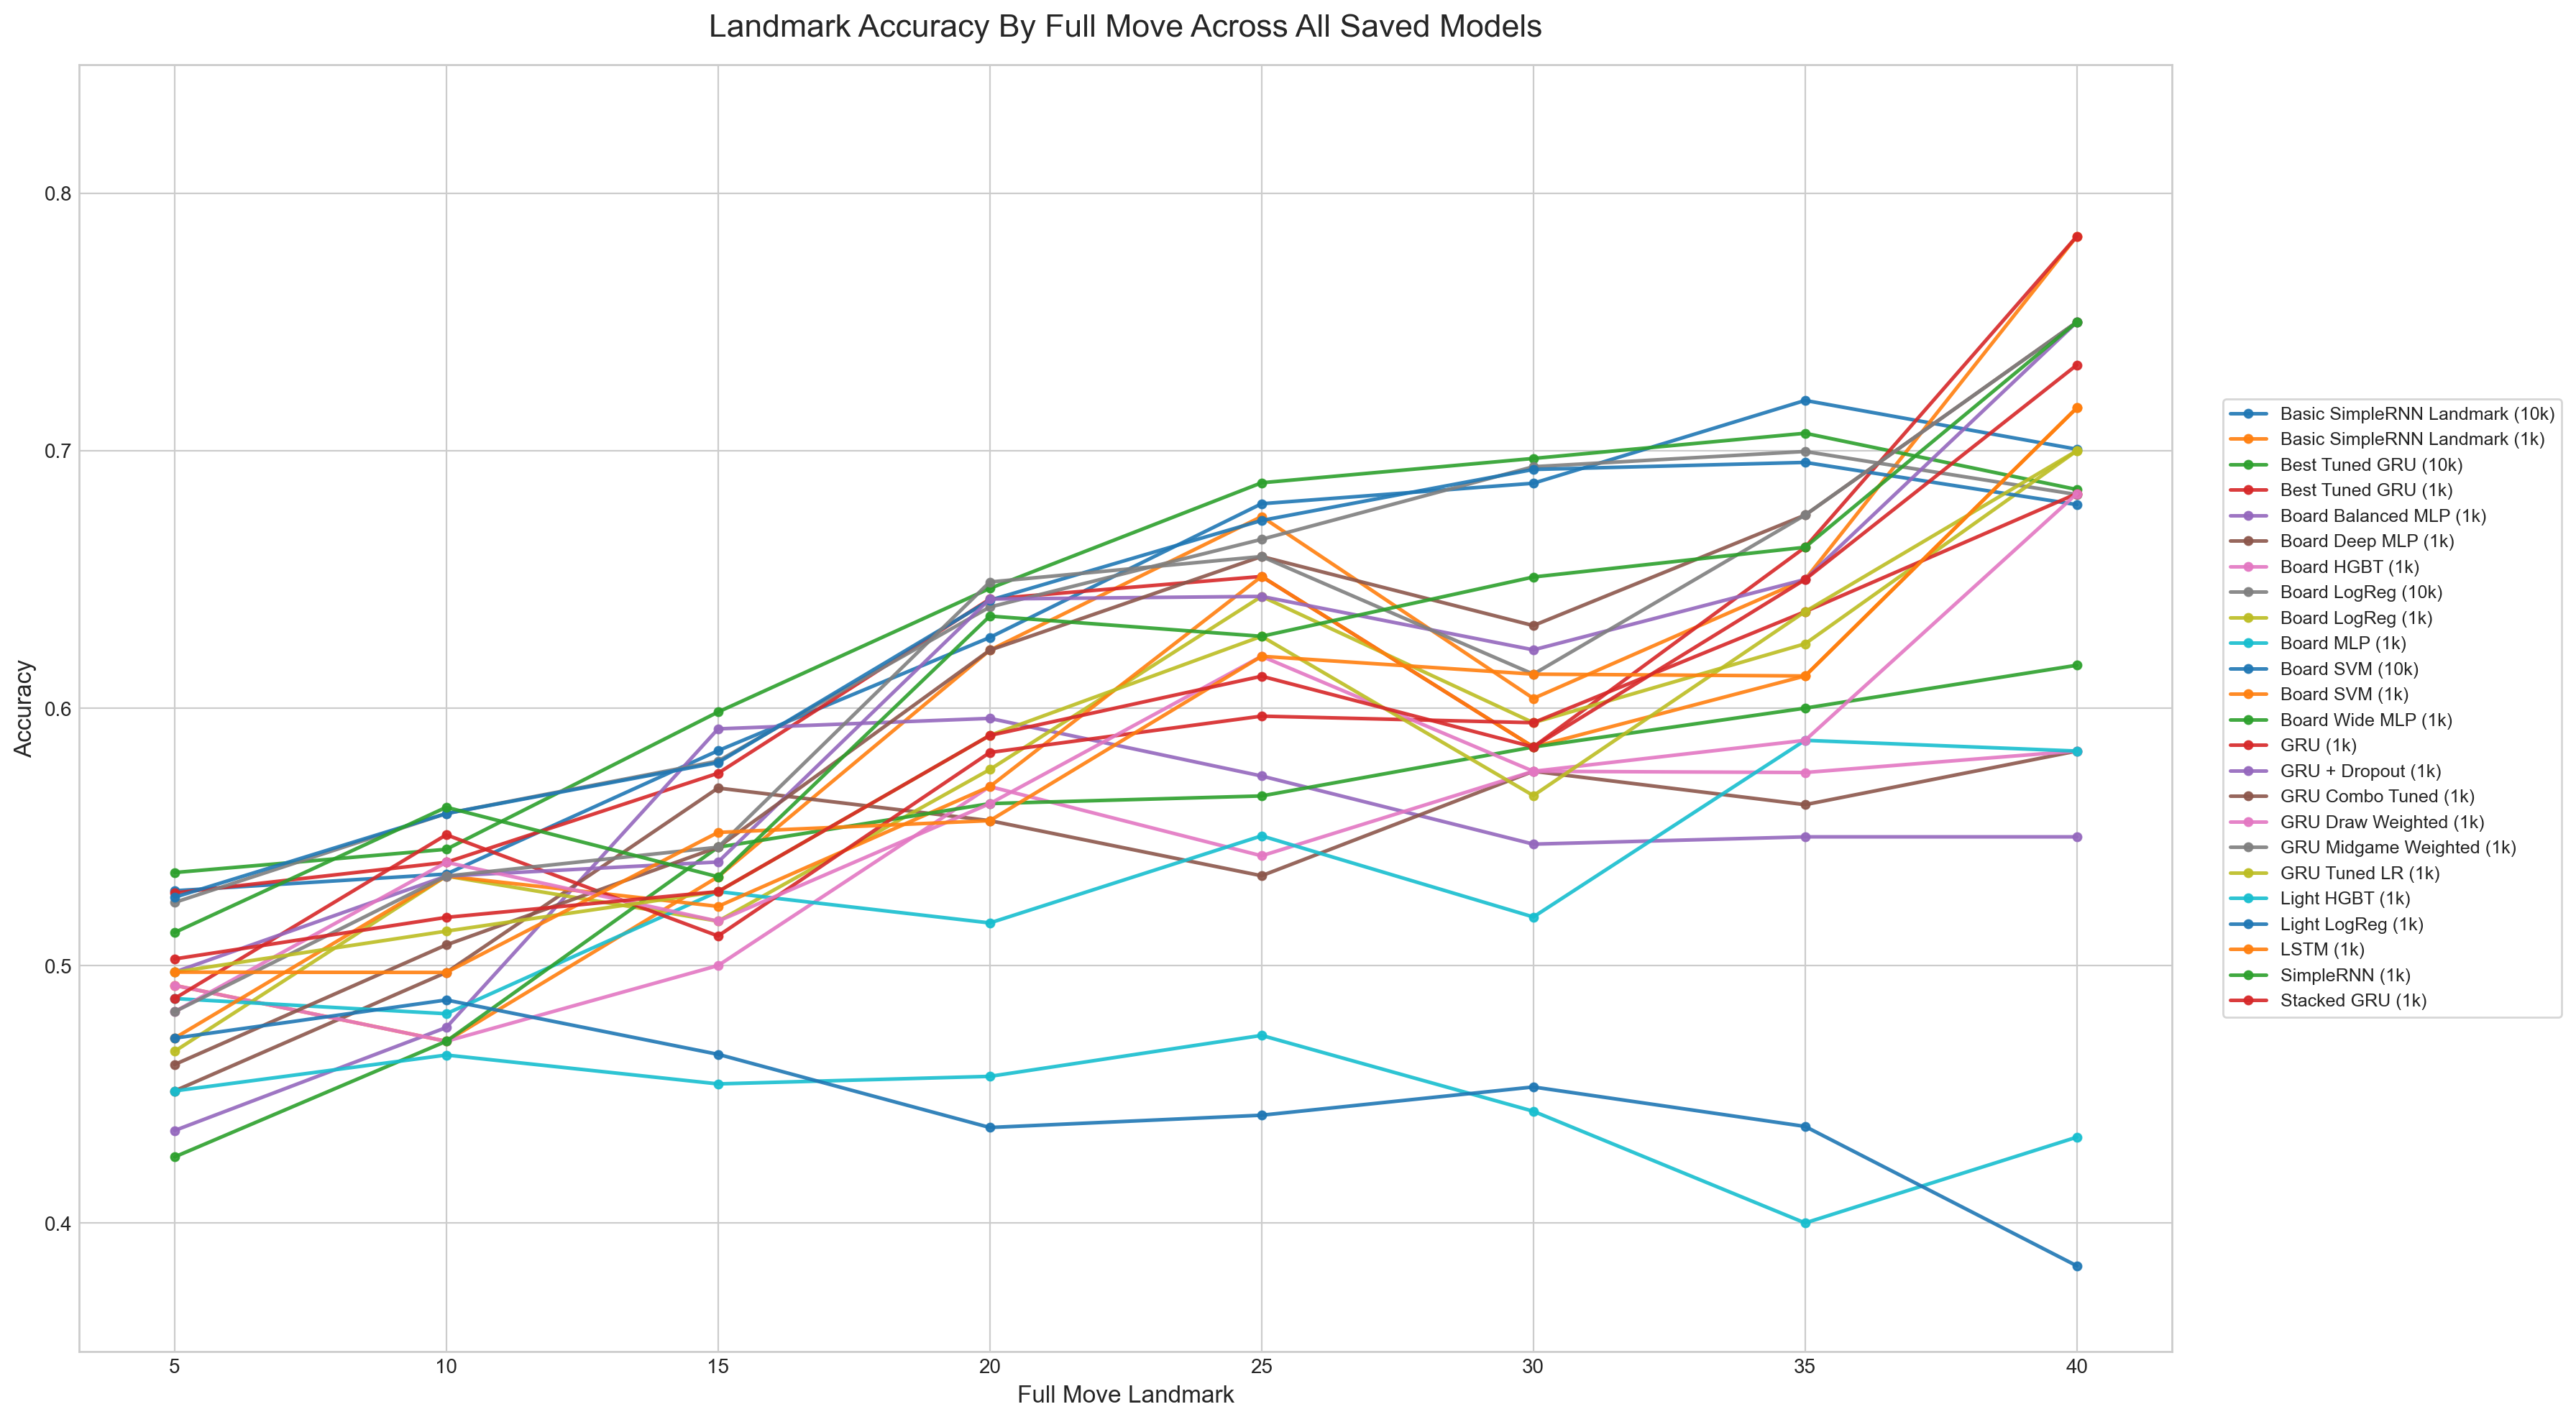

### Top 3 models at 50,000 games

I expanded to 50k to see whether the tuned GRU would catch up to the SimpleRNN. It didn't. It actually got worse relative to both the SimpleRNN and logistic regression, which suggests the tuning (dropout + midgame weighting) was overfit to the 1k development setting.

| Model | Test Accuracy | Test Log Loss | Avg Landmark Accuracy | Avg Landmark Brier | Move 5 Acc | Move 10 Acc | Move 20 Acc | Move 30 Acc | Move 40 Acc |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Board Logistic Regression (50k) | 0.618 | 0.783 | 0.673 | 0.436 | 0.522 | 0.550 | 0.631 | 0.688 | 0.732 |
| Basic SimpleRNN (50k) | 0.637 | 0.747 | 0.690 | 0.407 | 0.534 | 0.572 | 0.645 | 0.702 | 0.737 |
| Tuned GRU (50k) | 0.610 | 0.809 | 0.596 | 0.536 | 0.523 | 0.539 | 0.618 | 0.672 | 0.717 |

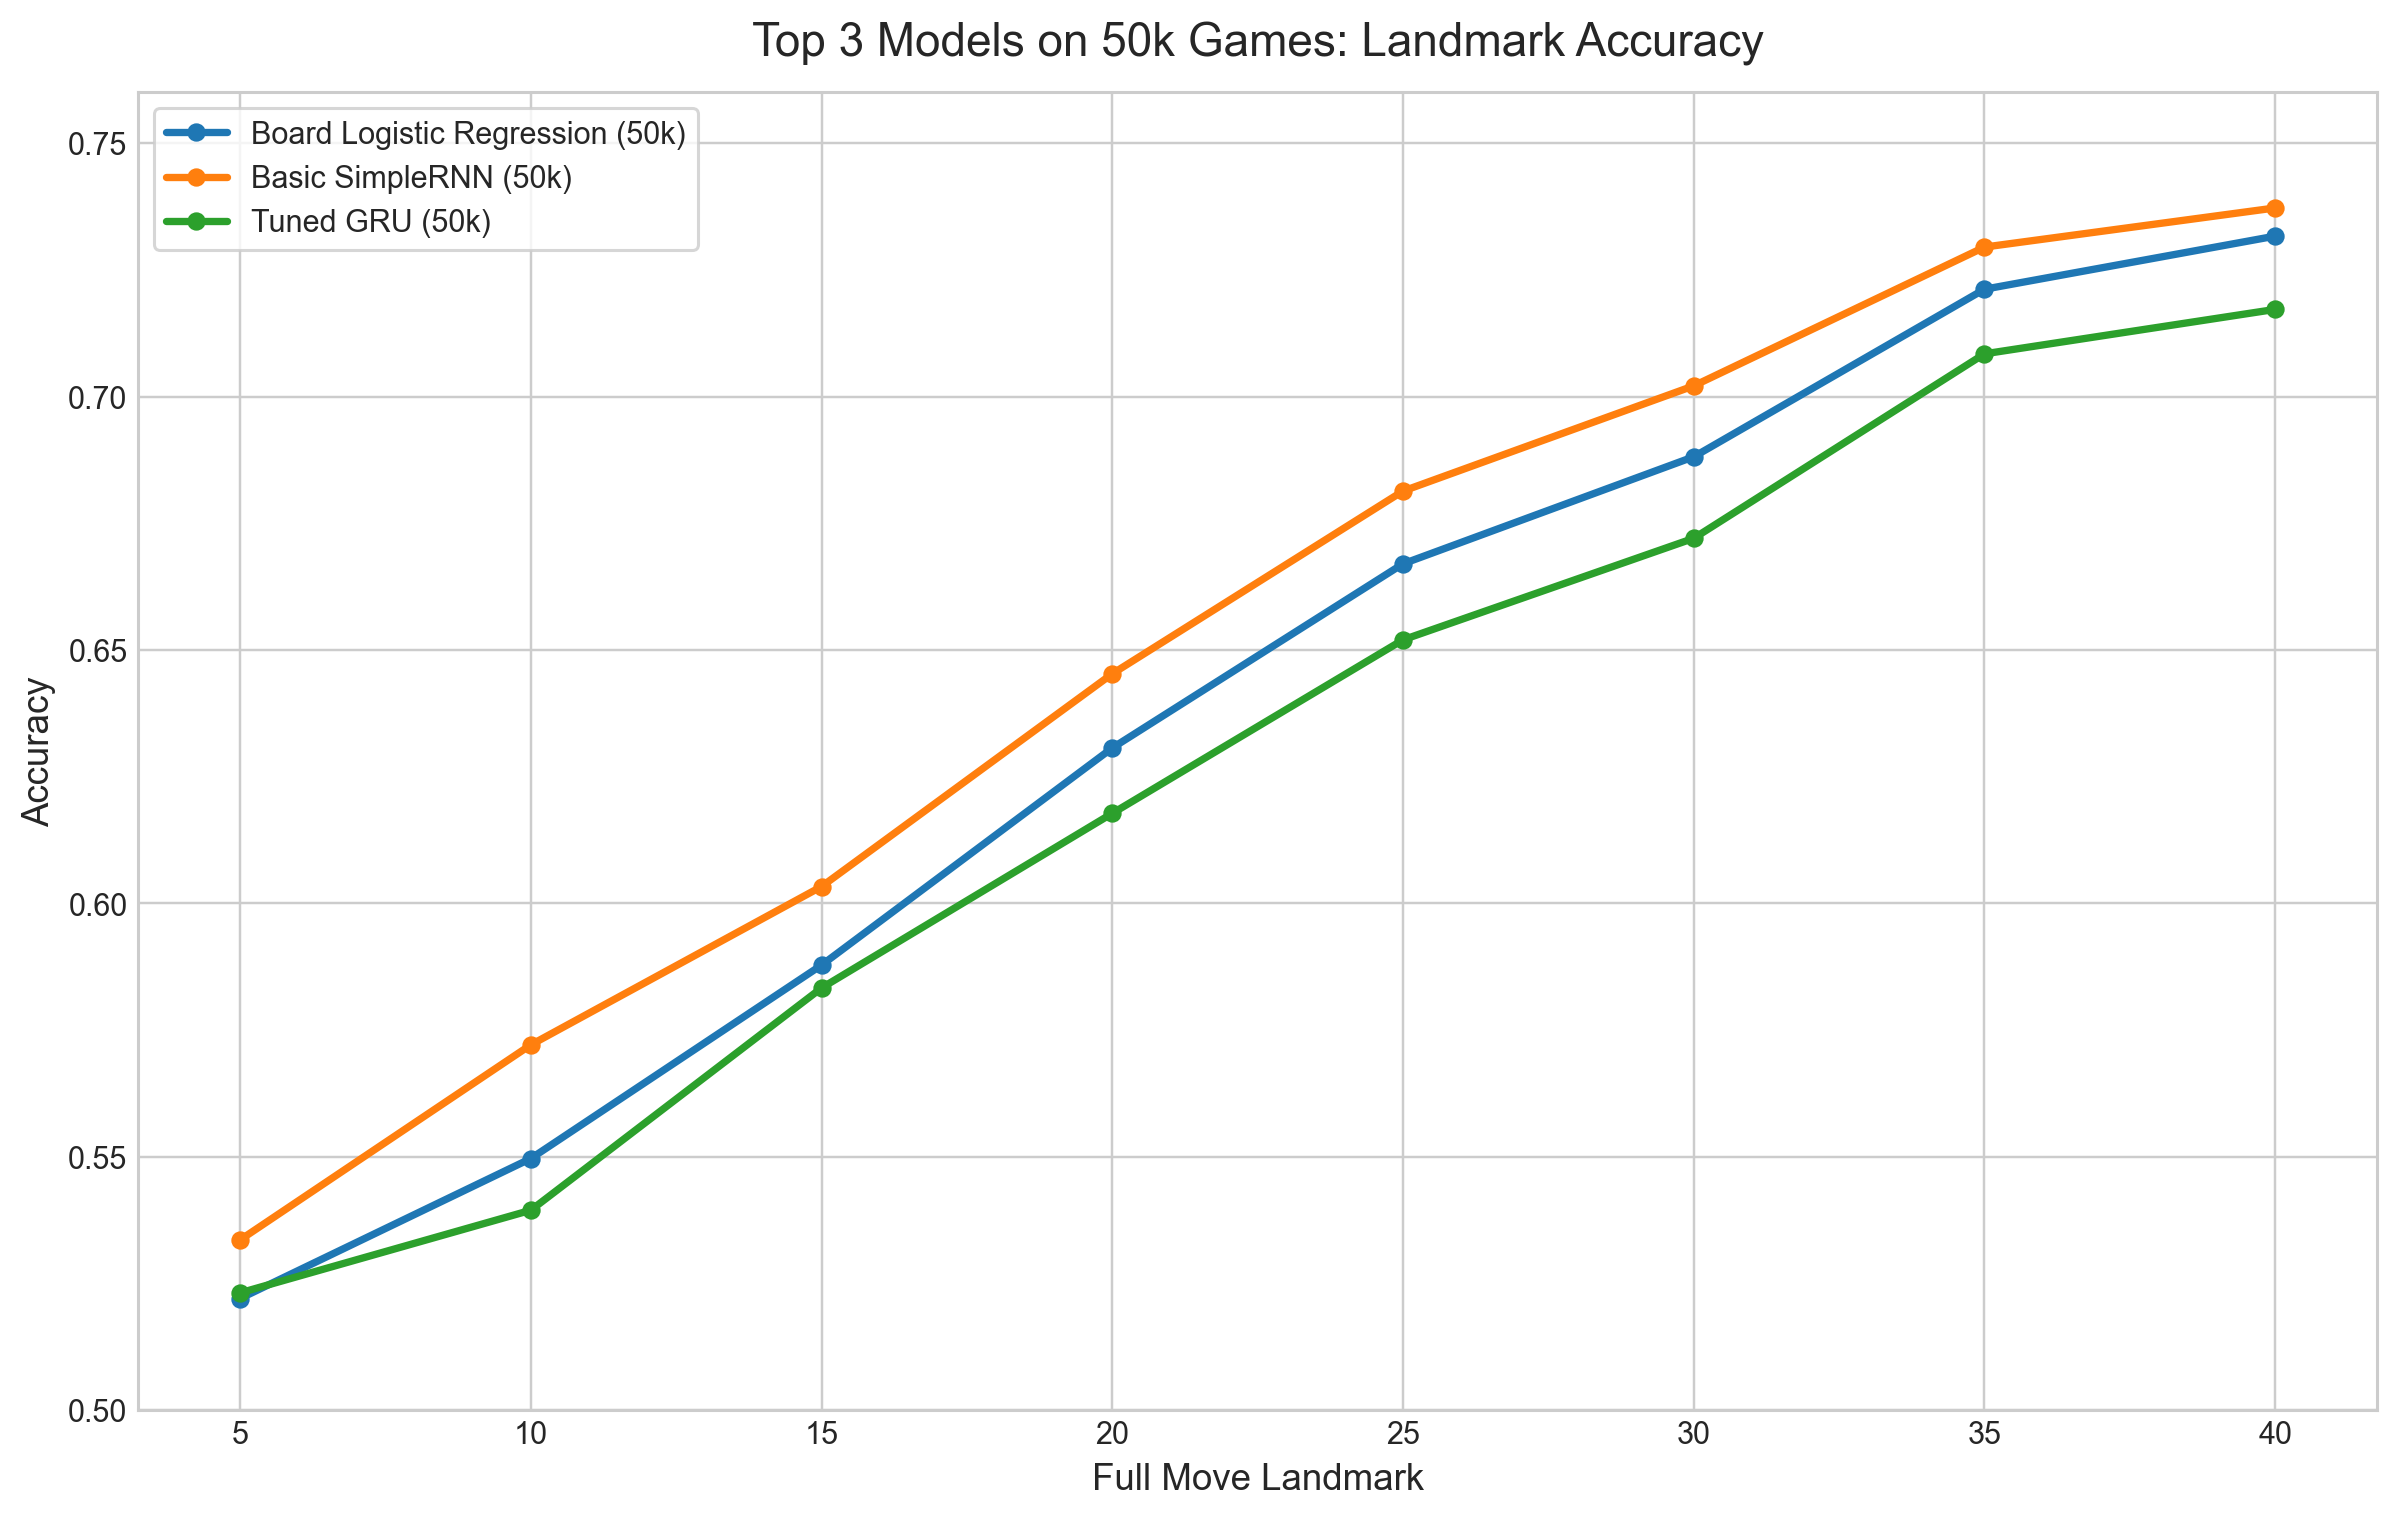

### Scaling the SimpleRNN

Once I had the shard-based pipeline working, I scaled the basic SimpleRNN from 1k games up to the full 8.63M. Results improved steadily:

| Dataset | Test Accuracy | Test Log Loss | Avg Landmark Accuracy | Avg Landmark Brier | Move 5 Acc | Move 10 Acc | Move 20 Acc | Move 30 Acc | Move 40 Acc |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1k | 0.598 | 0.807 | 0.628 | 0.471 | 0.492 | 0.471 | 0.623 | 0.604 | 0.783 |
| 10k | 0.615 | 0.774 | 0.672 | 0.424 | 0.529 | 0.536 | 0.627 | 0.687 | 0.701 |
| 50k | 0.637 | 0.747 | 0.690 | 0.407 | 0.534 | 0.572 | 0.645 | 0.702 | 0.737 |
| 100k | 0.631 | 0.755 | 0.700 | 0.403 | 0.529 | 0.560 | 0.644 | 0.700 | 0.718 |
| 250k | 0.628 | 0.763 | 0.689 | 0.420 | 0.529 | 0.555 | 0.640 | 0.703 | 0.714 |
| 1M | 0.634 | 0.753 | 0.704 | 0.396 | 0.532 | 0.562 | 0.646 | 0.706 | 0.722 |
| 8.63M | 0.636 | 0.749 | 0.742 | 0.353 | 0.534 | 0.563 | 0.650 | 0.709 | 0.724 |

The 100k and 250k runs were slightly weaker than 50k, which I think is just training noise rather than a real trend. By 1M and the full dataset, things were clearly better. The gains slowed down past 1M but didn't flatten out.

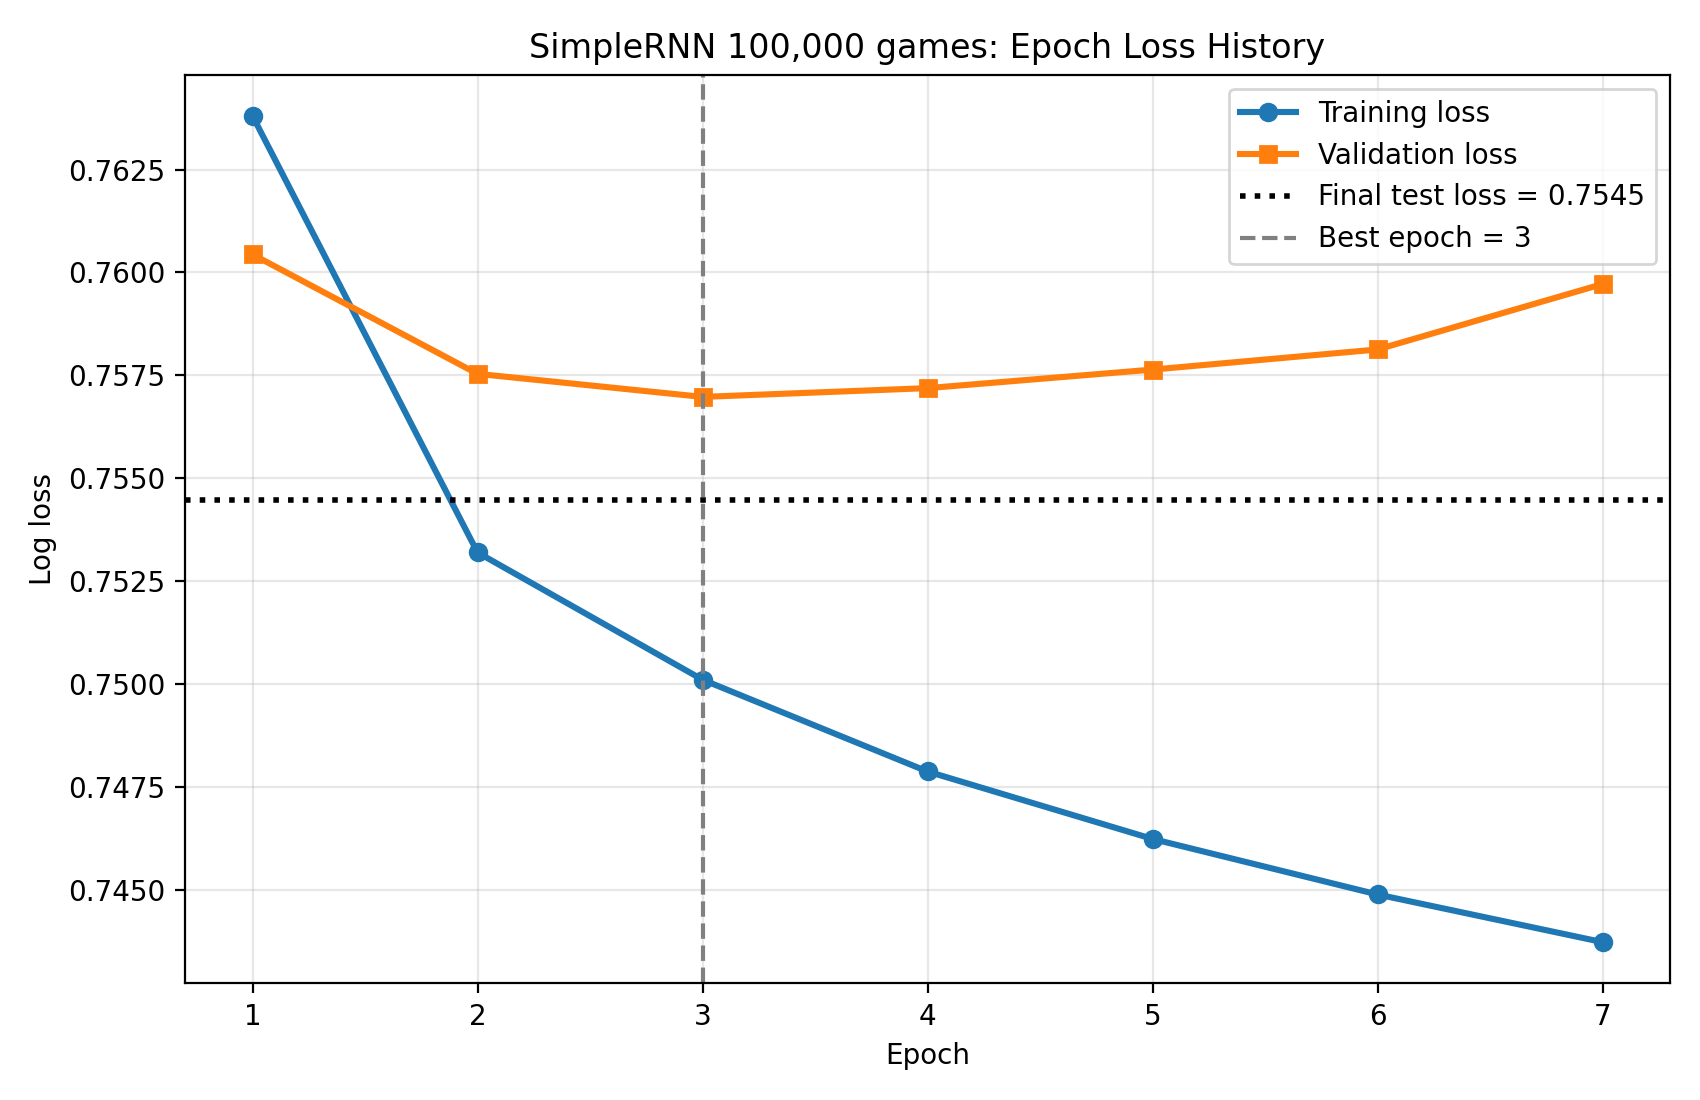

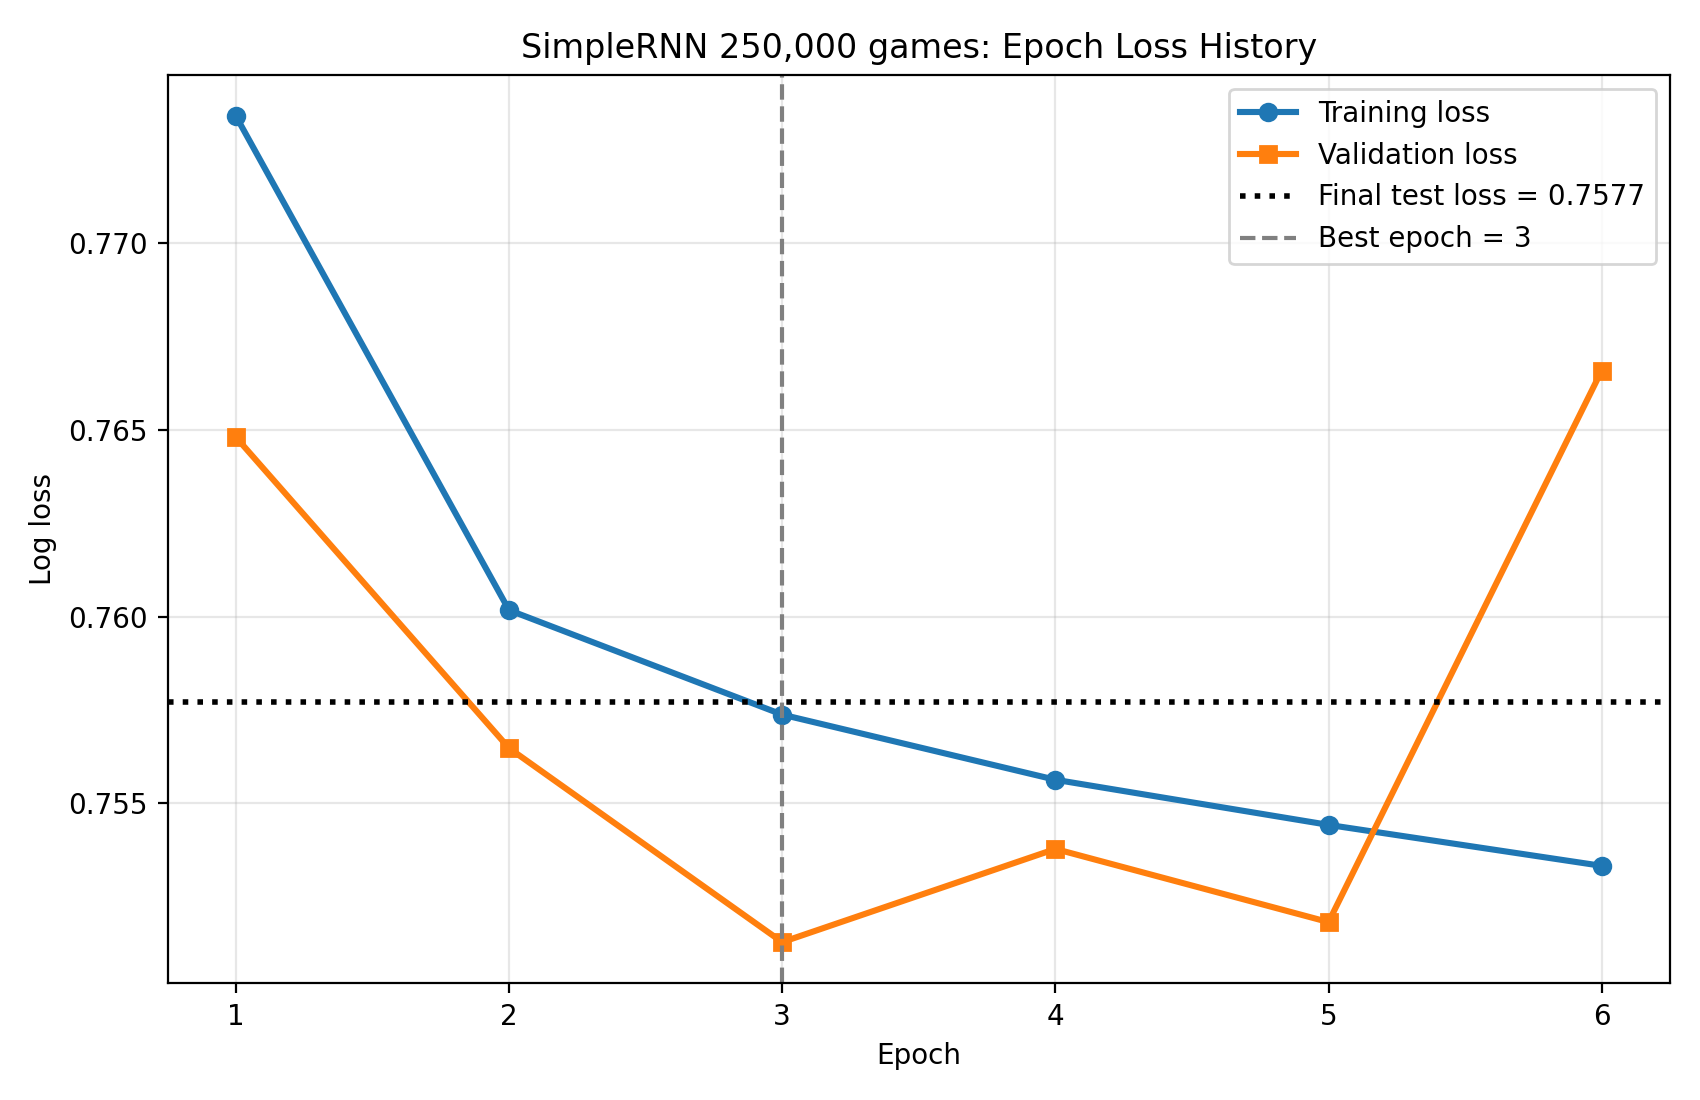

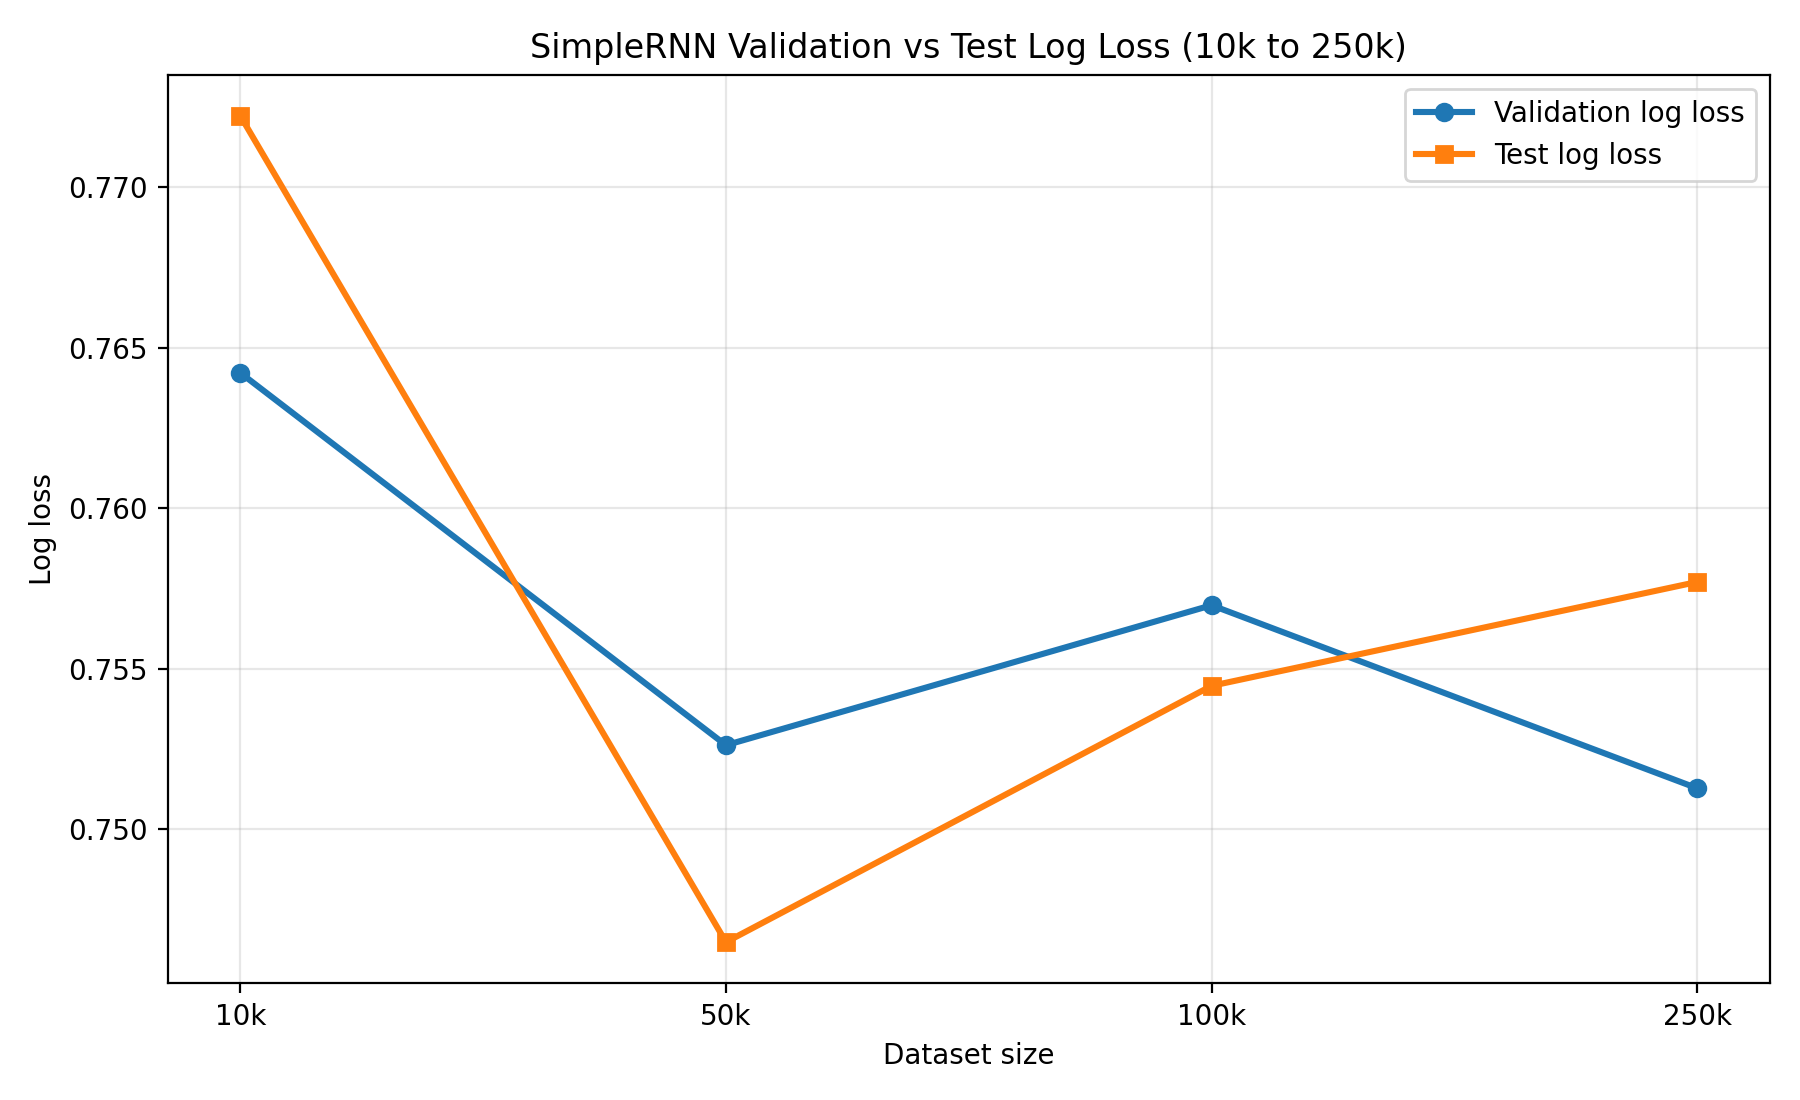

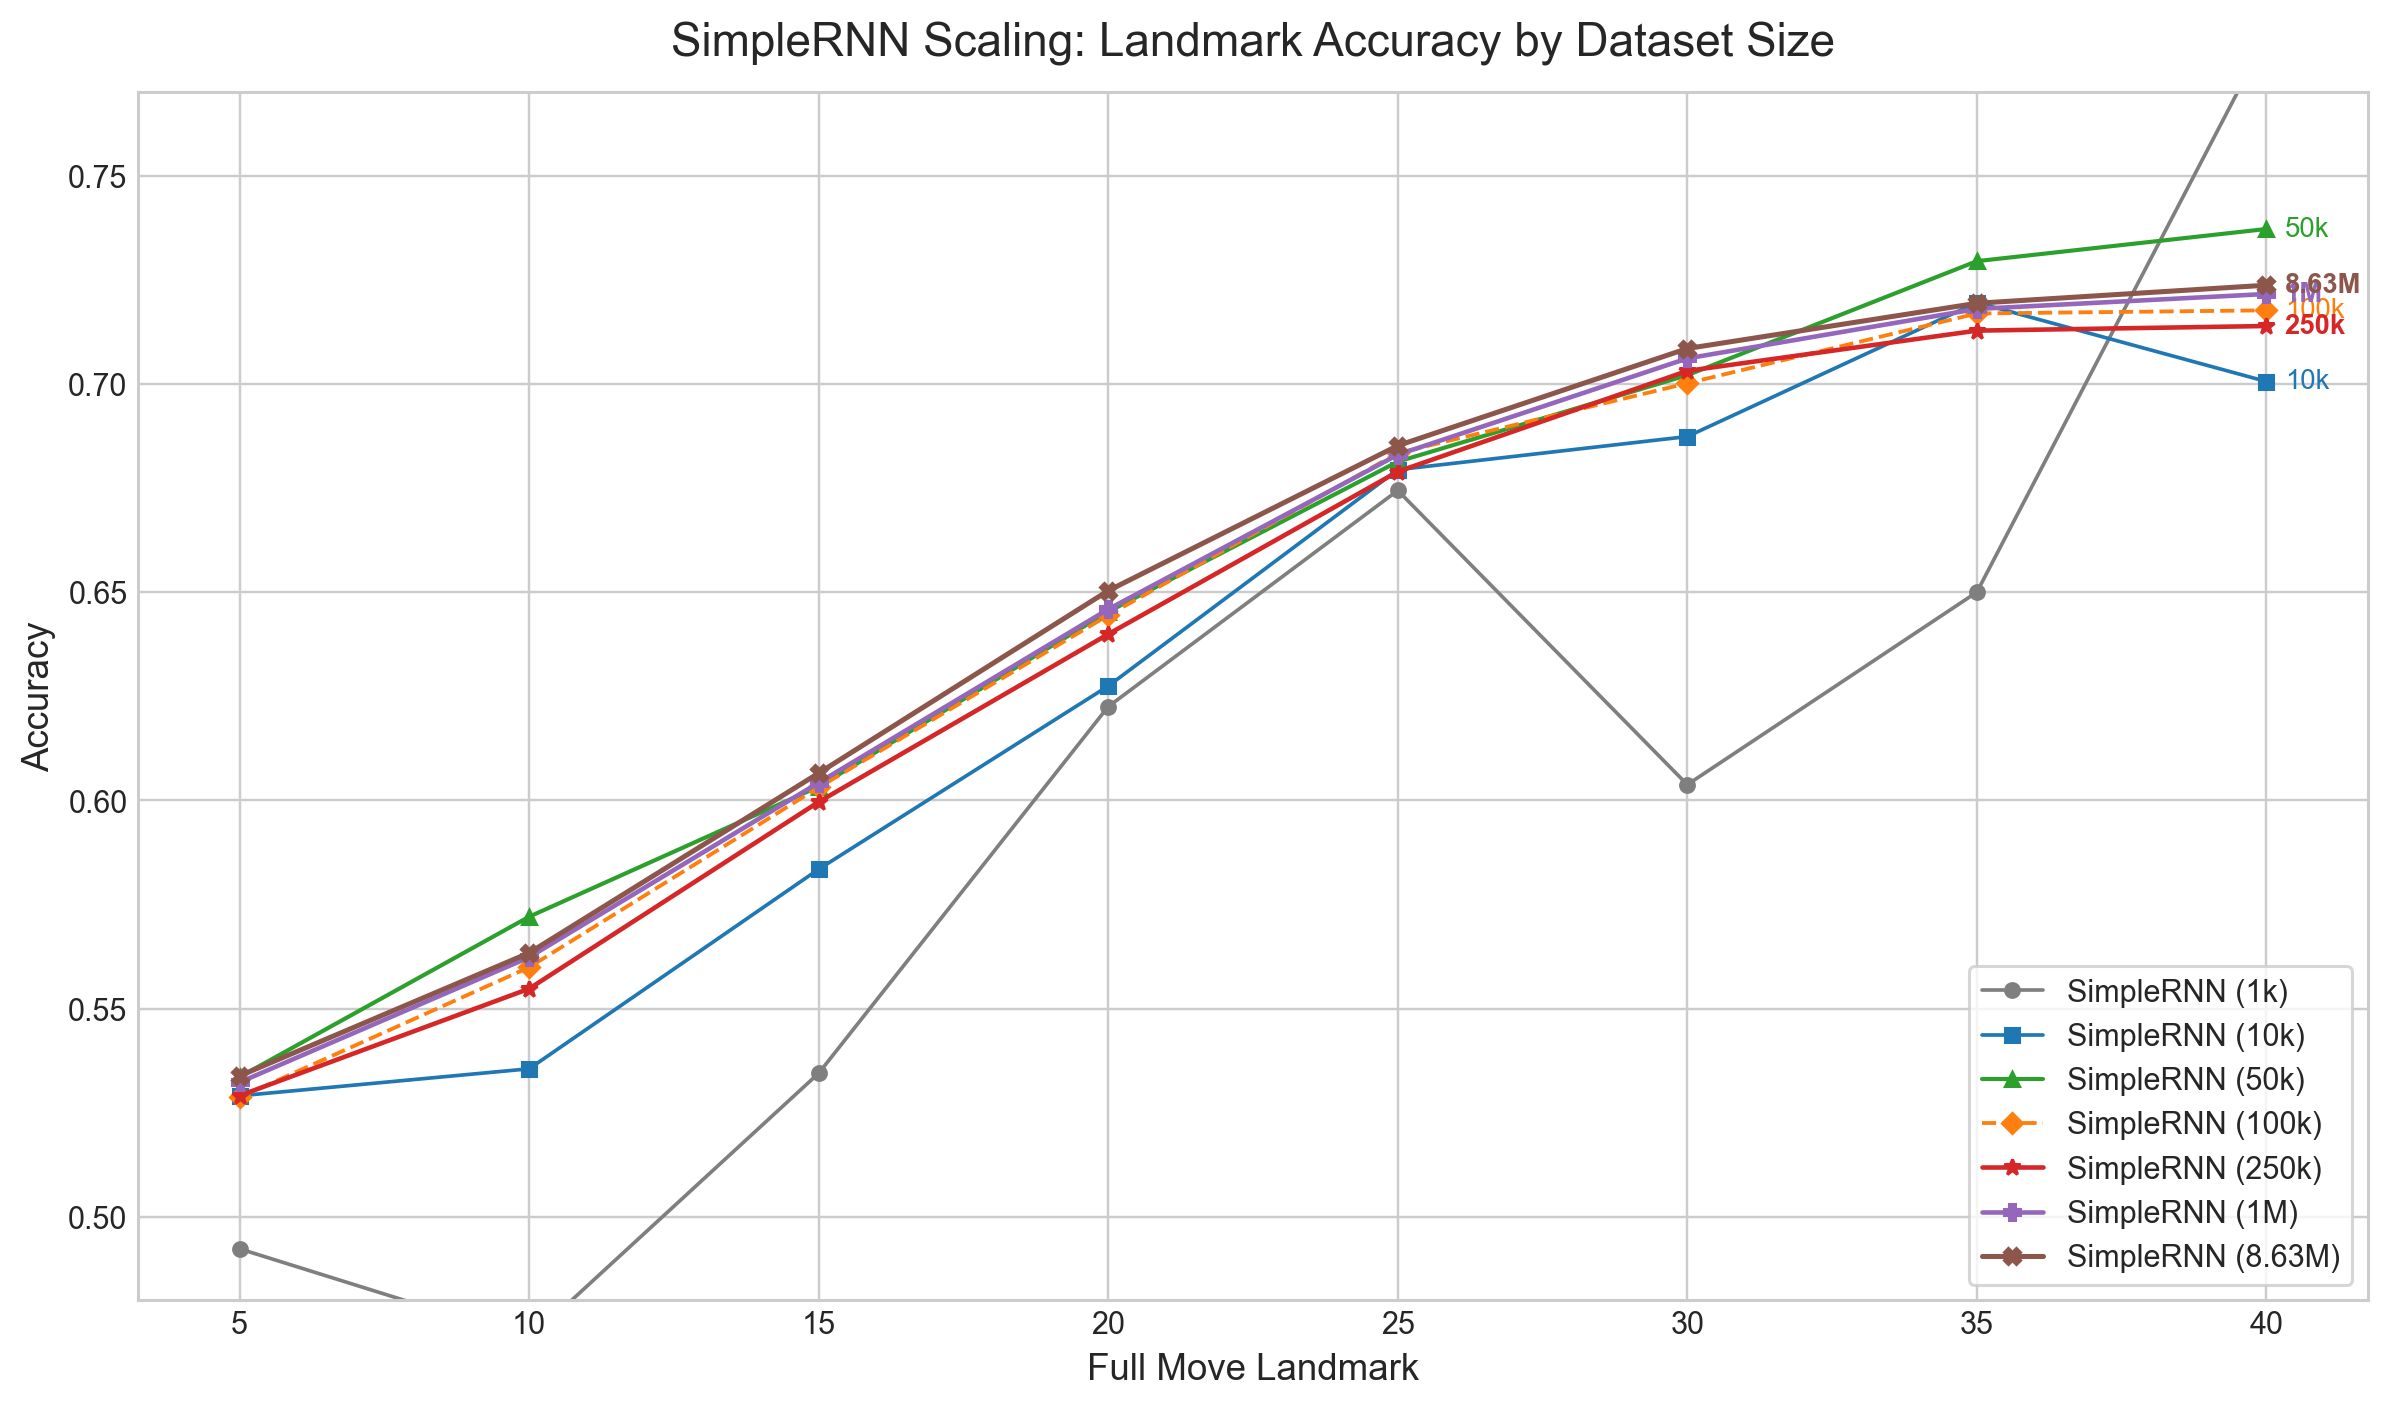

### RNN variant sweep on 1,000 games

> **Note on the sweep results:** The Test Accuracy and Test Log Loss shown here (`0.614` / `0.815` for the plain SimpleRNN) differ slightly from the `1k` row in the Overall Comparison table (`0.598` / `0.807`). Both use the same `1,000`-game board-aware dataset but from separate training runs with different random seeds. The sweep is reported as-is so the relative comparison between variants remains valid.

| RNN Variant | Key Settings | Test Accuracy | Test Log Loss | Avg Landmark Accuracy | Avg Landmark Brier | Move 5 Acc | Move 10 Acc | Move 20 Acc | Move 30 Acc | Move 40 Acc |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| SimpleRNN | `SimpleRNN(64)`, `lr=1e-3`, `batch=64` | 0.614 | 0.815 | 0.638 | 0.478 | 0.513 | 0.562 | 0.636 | 0.651 | 0.750 |
| GRU | `GRU(64)`, `lr=1e-3`, `batch=64` | 0.582 | 0.842 | 0.603 | 0.486 | N/A | N/A | N/A | N/A | N/A |
| LSTM | `LSTM(64)`, `lr=1e-3`, `batch=64` | 0.585 | 0.821 | 0.616 | 0.488 | N/A | N/A | N/A | N/A | N/A |
| Stacked GRU | `GRU(64,64)`, `lr=1e-3`, `batch=64` | 0.595 | 0.820 | 0.624 | 0.476 | N/A | N/A | N/A | N/A | N/A |
| GRU + Dropout | `GRU(64)`, `dropout=0.2`, `rec_dropout=0.1` | 0.613 | 0.787 | 0.633 | 0.468 | N/A | N/A | N/A | N/A | N/A |
| GRU Tuned LR | `GRU(64)`, `lr=5e-4`, `batch=128`, `epochs=40` | 0.586 | 0.832 | 0.610 | 0.490 | N/A | N/A | N/A | N/A | N/A |
| GRU Midgame Weighted | `GRU(64)`, weight moves `20-50` by `1.5` | 0.607 | 0.790 | 0.634 | 0.458 | N/A | N/A | N/A | N/A | N/A |
| GRU Draw Weighted | `GRU(64)`, draw weight `2.0` | 0.578 | 0.838 | 0.593 | 0.493 | N/A | N/A | N/A | N/A | N/A |
| GRU Dropout + Midgame Weighting | `GRU(64)`, `dropout=0.2`, `rec_dropout=0.1`, weight moves `20-50` by `1.5` | 0.619 | 0.774 | 0.637 | 0.442 | 0.528 | 0.540 | 0.642 | 0.585 | 0.783 |

### Landmark accuracy across game stages

Every board-aware and recurrent model shows the same pattern: accuracy is low in the opening where the position is still open, and climbs through the middlegame and endgame. The light-feature models sit around `44%` average landmark accuracy throughout and don't really improve with game stage. The board-aware gap is visible from around move 10 and keeps widening.

## **Conclusions**

The main thing I took away from this project is that feature engineering mattered far more than model choice. Switching from light features to board-aware features while keeping logistic regression was worth more than any architecture change I tried. The calibrated SVM matched logistic regression almost exactly, and both beat MLPs and gradient boosting in probability calibration, even though MLPs are nominally more powerful.

Recurrent models were the right tool for this problem. Seeing the game sequence rather than a single snapshot gave them a structural advantage that showed up consistently under landmark evaluation. The SimpleRNN scaled cleanly from 1k to 8.63M games, ending at `63.6%` test accuracy and a `74.2%` average landmark accuracy. The gains past 1M were small but still there.

The landmark evaluation design ended up being important. A single pooled accuracy number would hide the fact that the model is basically guessing in the opening (`53.4%` at move 5) and gets much more reliable by moves 30-40 (`72.4%`). Reporting both gives a more honest picture.

There are obvious things I didn't get to. The draw class is consistently hard to predict; every model mostly just picks White win or Black win and accepts the draw misclassification rate. Adding raw board position encoding (piece-square maps or a small CNN layer) would probably help the RNN a lot. And the full-scale extraction and training was slow enough that I couldn't iterate as fast as I would have liked on the shard-based pipeline. Checkpoint/resume saved me there but it still took several hours per full run.

## **References**
- Lichess Open Database. Official website and data source: https://database.lichess.org/ . Used as the raw PGN source for all experiments.
- `python-chess` documentation: https://python-chess.readthedocs.io/ . Used for PGN parsing and legal board reconstruction.
- scikit-learn documentation: https://scikit-learn.org/stable/ . Used for logistic regression, calibrated SVM, histogram gradient boosting, and MLP baselines.
- TensorFlow documentation: https://www.tensorflow.org/ and Keras documentation: https://keras.io/ . Used for the earlier recurrent-neural-network experiments.
- PyTorch documentation: https://pytorch.org/docs/stable/index.html . Used for the shard-based GPU SimpleRNN experiments at larger scale.
- XGBoost documentation: https://xgboost.readthedocs.io/ . Used for the later board-aware boosted-tree comparison.
- Course Project Guidelines document and Course Material
